# Plotting The CSVs created by the other Notebooks
most of these were initially plotted in `./demo_num_investigations.ipynb` however, it made it look messy and was hard to find what I needed, this is a more structured and I think overall better system to plot things

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


import numpy as np
import pandas as pd

import seaborn as sns
import torch

import re
from itertools import product

## Helpers


In [2]:
def parse_list(ss: str):
  s = ss.strip("[]")
  # print(s)
  s = re.sub(r"\s+", " ", s)
  return np.fromstring(s, sep=" ")

def parse_list_bools(ss: str):
  global count
  s = ss.strip("[]")
  s = re.sub(r"\s+", " ", s)
  bools = s.split(" ")
  return np.array([b == 'True' for b in bools], dtype=bool)

# No Obstacle


## Different Camera Combinations, Single Cams



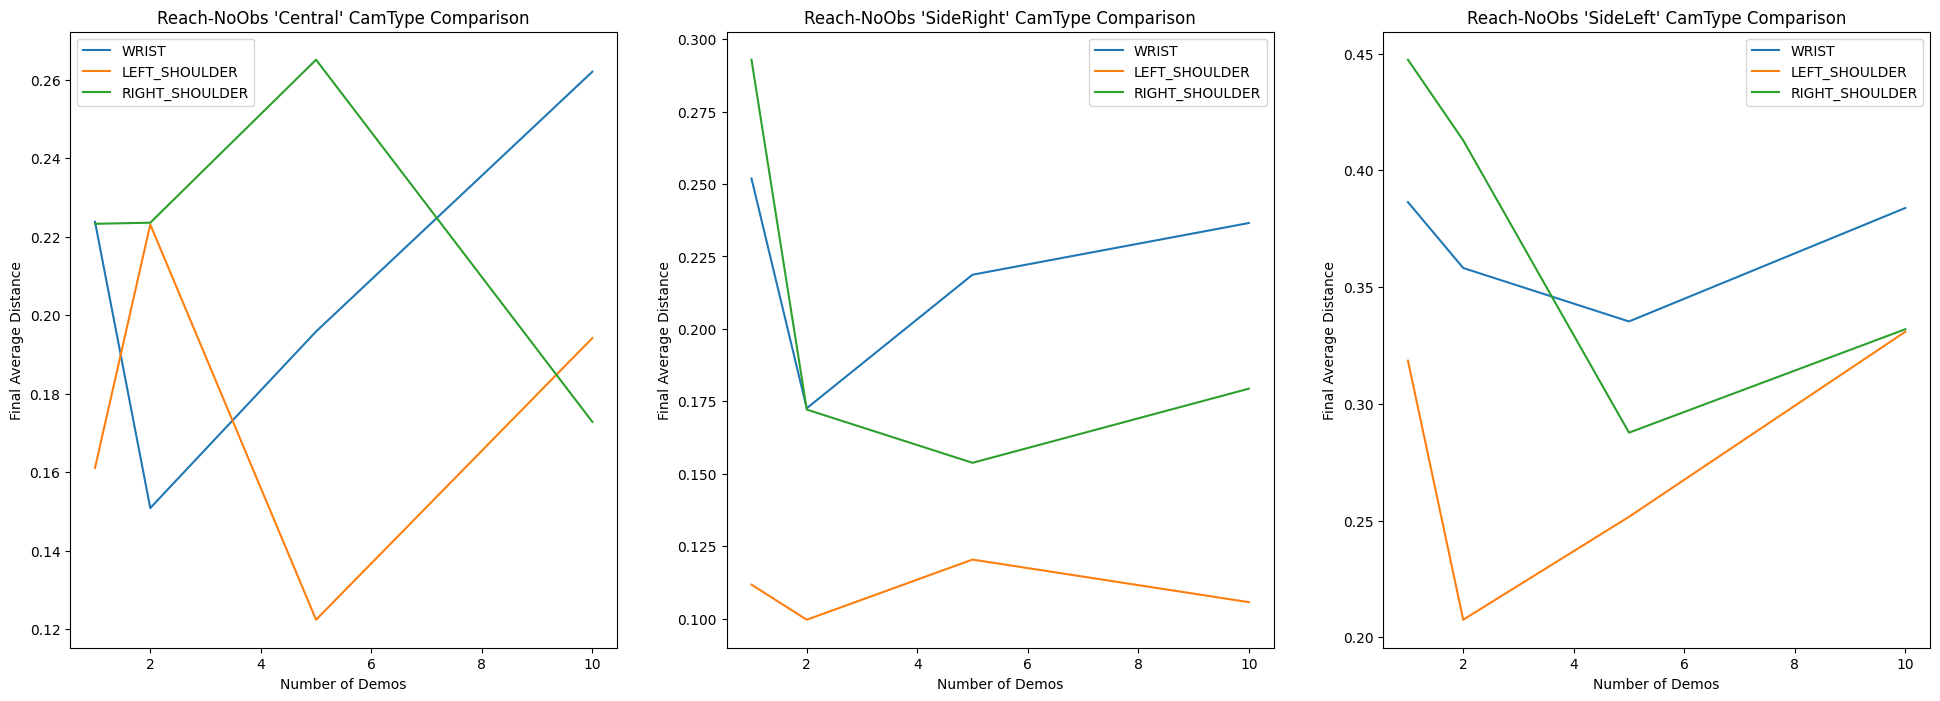

In [35]:
df = pd.read_csv("run-csvs/reach-no-obs/diff_cams-results.csv")

tasks = df["task"].unique()
fig, ax = plt.subplots(1, len(tasks), figsize=(24, 8))

for ti, task in enumerate(tasks):
  task_df = df[df["task"] == task]
  
  for cam_type in task_df["cam_type"].unique():
    cam_df = task_df[task_df["cam_type"] == cam_type]
    ax[ti].plot(cam_df["demo_count"], cam_df["final_dist"], label=cam_type)
    
  ax[ti].set_title(f"Reach-NoObs '{task}' CamType Comparison")
  ax[ti].set_xlabel("Number of Demos")
  ax[ti].set_ylabel("Final Average Distance")
  ax[ti].legend()



## Random Place - Different Cam Results

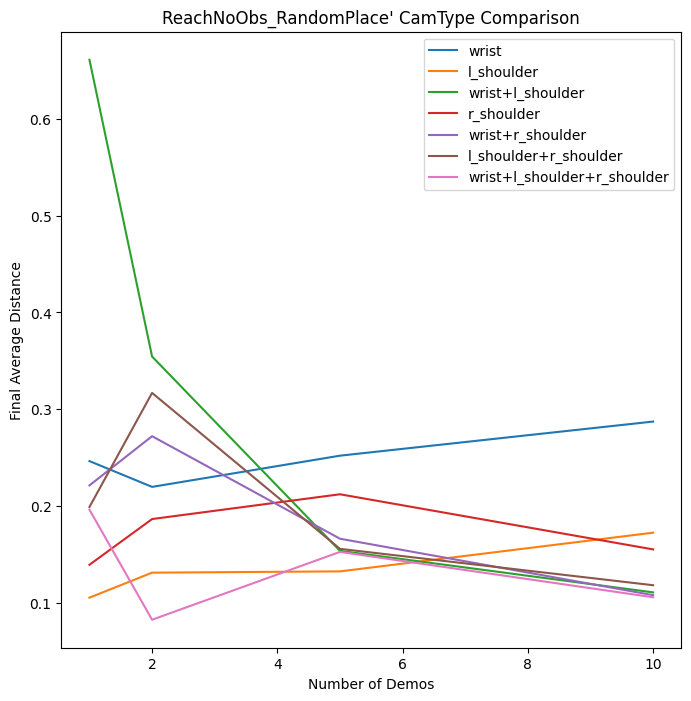

In [74]:
df = pd.read_csv("run-csvs/reach-no-obs/random_place-multicam-results.csv")
df["cam_type"] = df["cam_type"].apply(lambda x: re.sub(r"^\+", "", x))
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

sns.lineplot(data=df, x="demo_count", y="final_dist", hue="cam_type", ax=ax)
  
ax.set_title(f"ReachNoObs_RandomPlace' CamType Comparison")
ax.set_xlabel("Number of Demos")
ax.set_ylabel("Final Average Distance")
ax.legend()



## `Reach_PlaceRandom` Epoch Trials
trying 1000 and 500 epochs to see which one is better at Beheaviourally Cloning this task


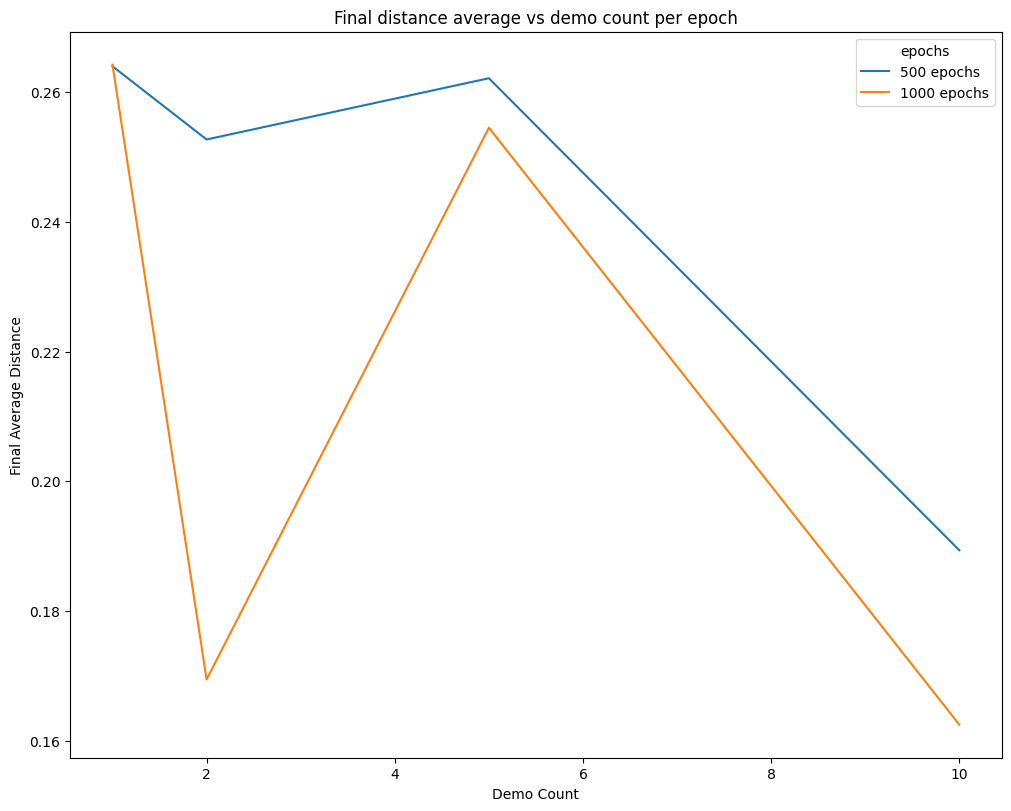

In [31]:
figsize = 10, 8
fix, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout = True)

## load the data df

df500 = pd.read_csv(f"run-csvs/reach-no-obs/1-2-5-10-10repeats-diff-initial-poses-no_obs-500epochs.csv")
df500["epoch"] = 500
df1000 = pd.read_csv(f"run-csvs/reach-no-obs/1-2-5-10-10repeats-diff-initial-poses-no_obs-1000epochs.csv")
df1000["epoch"] = 1000


ax.plot(df500["demo_count"], df500["final_dist_avg"], label = "500 epochs")
ax.plot(df1000["demo_count"], df1000["final_dist_avg"], label = "1000 epochs")

ax.set_title("Final distance average vs demo count per epoch")
ax.set_xlabel("Demo Count")
ax.set_ylabel("Final Average Distance")
ax.legend(title="epochs")


# for i in range(2):
#   plt.plot(df["demo_count"], df["final_dist_avg"], label = f"demo_count {i+1}")

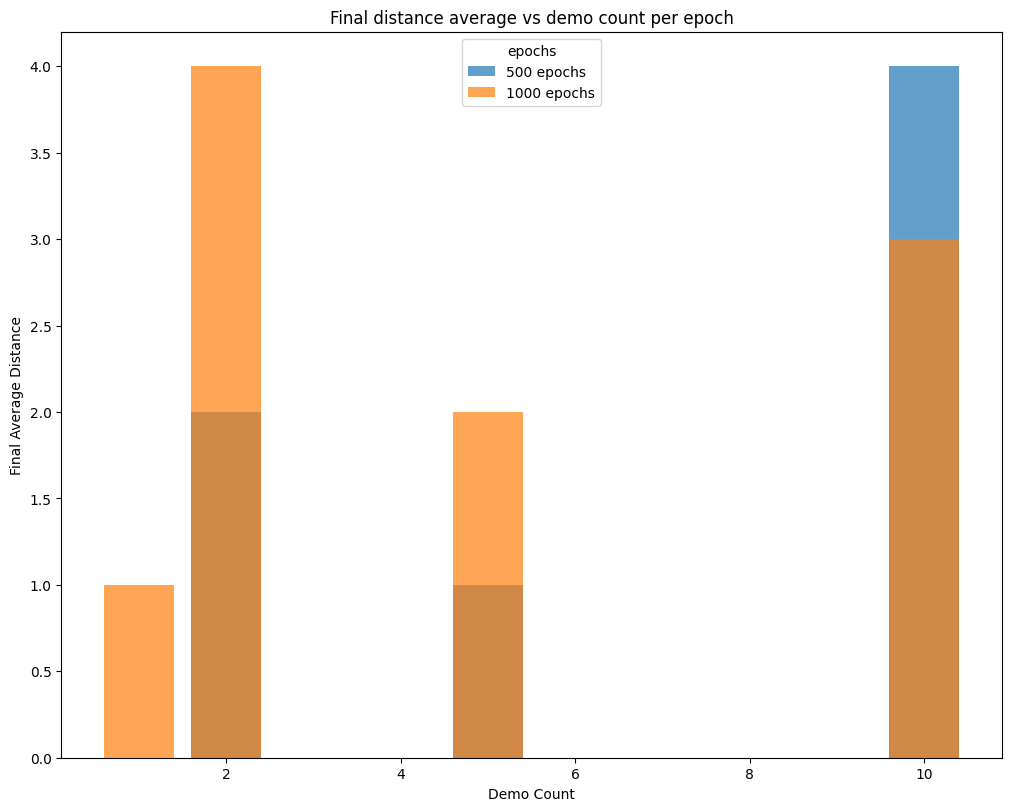

In [32]:
fix, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout = True)
ax.bar(df500["demo_count"], df500["reached_count"], label = "500 epochs", alpha = 0.7)
ax.bar(df1000["demo_count"], df1000["reached_count"], label = "1000 epochs", alpha = 0.7)

ax.set_title("Final distance average vs demo count per epoch")
ax.set_xlabel("Demo Count")
ax.set_ylabel("Final Average Distance")
ax.legend(title="epochs")
plt.show()

# Reach With Obstacle


## Using the Same Unchanhed Policy from NoObs
Will not be looking at the reached counts, at this point there was no way of checking within err `within_err` in `run_task`, and this did not perform well anyway

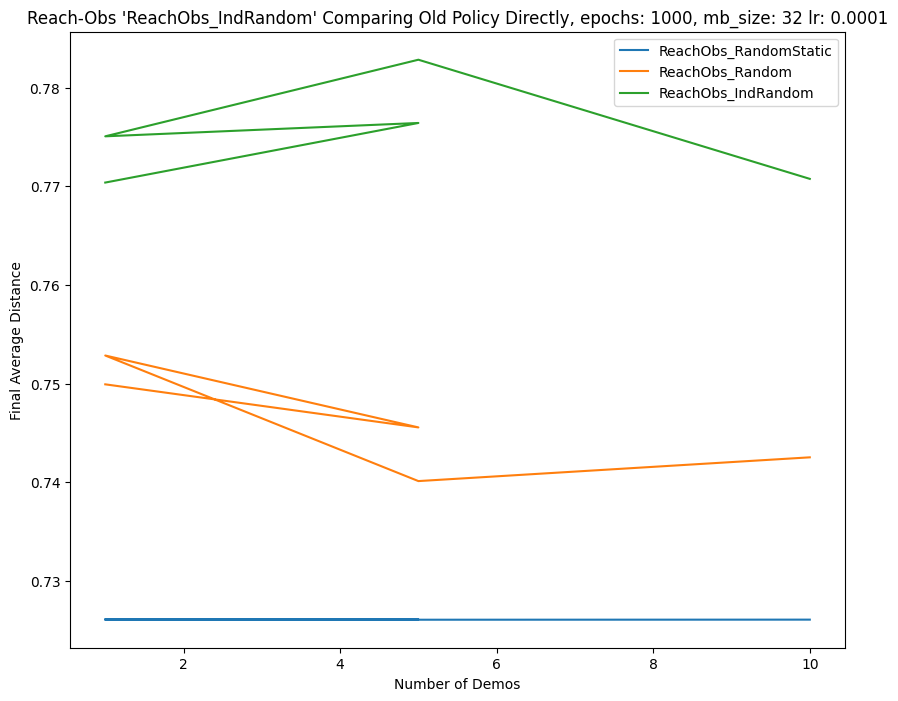

In [41]:
df = pd.read_csv("run-csvs/reach-obs/policy-improvement-resutls.csv")
df

epoch = 1000
mb = 32
lr = 0.0001
tasks = df["task_name"].unique()

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
for task in tasks:
  task_df = df[df["task_name"] == task]
  ax.plot(task_df["demo_count"], task_df["final_dist_avg"], label=task)
  
    
  ax.set_title(f"Reach-Obs '{task}' Comparing Old Policy Directly, epochs: {epoch}, mb_size: {mb} lr: {lr}")
  ax.set_xlabel("Number of Demos")
  ax.set_ylabel("Final Average Distance")
  ax.legend()
plt.show()

## Checking Policy Imrovements
done on task: `ReachObs_Random`

The main checks are more training and more demos

tried:
```python
demos = [5, 10, 15, 20]
{
  "epochs": [500, 1000]
  "mb_size": 64, 
  "lr": 0.01 ## newer systems are using cosiune annealing!
}
```
still not bery good, not consistently reaching need to find a better strategy to teach


In [57]:
df500 = pd.read_csv("run-csvs/reach-obs/5-10-15-20-SAME-demos-camtype-comparison-reachobs_random-500-001-64.csv")
df1000 = pd.read_csv("run-csvs/reach-obs/5-10-15-20-SAME-demos-camtype-comparison-reachobs_random-1000-001-64.csv")

df500["reached_count"] = df500["has_reached"].apply(lambda row: parse_list_bools(row).sum())
df1000["reached_count"] = df1000["has_reached"].apply(lambda row: parse_list_bools(row).sum())



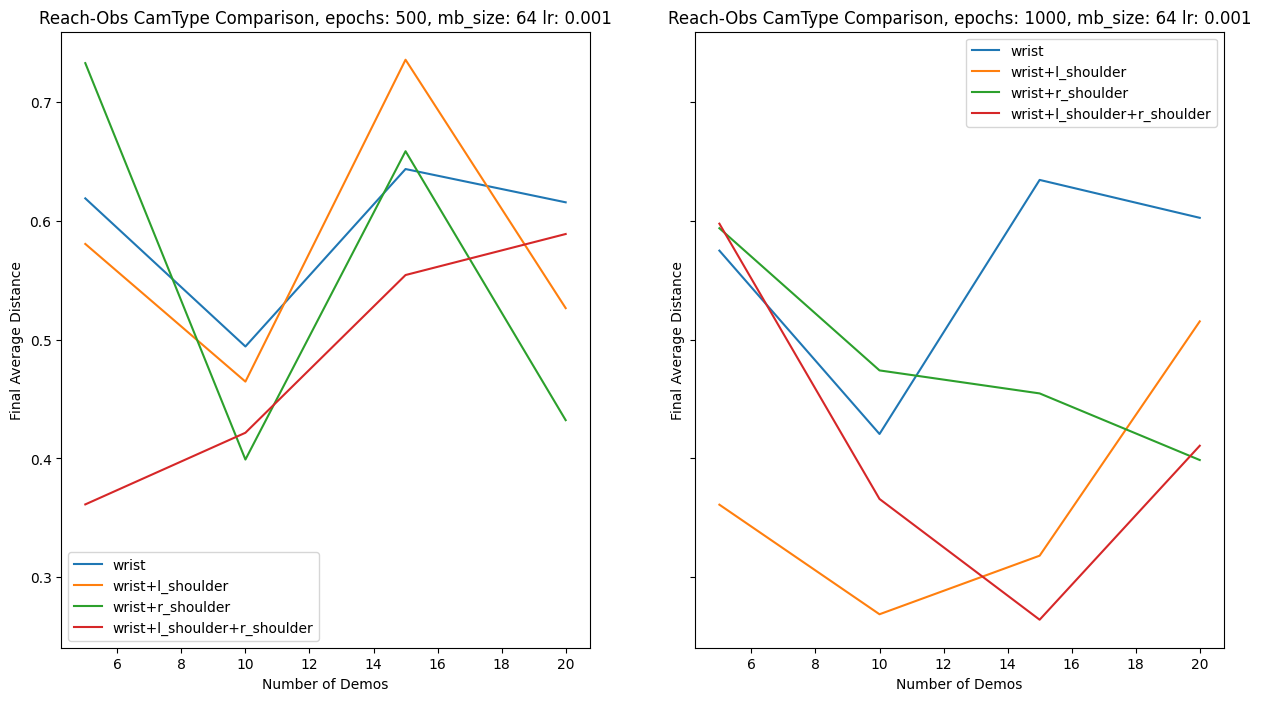

In [61]:
figsize = 15, 8
fig, ax = plt.subplots(1, 2, figsize=figsize, sharey=True)

cam_types = df500["cam_type"].unique()
dfs = [df500, df1000]
epochs = [500, 1000]
mb = 64
lr = 0.001

for di, df in enumerate(dfs):
  for cam_type in cam_types:
    cam_df = df[df["cam_type"] == cam_type]
    ax[di].plot(cam_df["demo_count"], cam_df["final_dist_avg"], label=cam_type)
    
  ax[di].set_title(f"Reach-Obs CamType Comparison, epochs: {epochs[di]}, mb_size: {mb} lr: {lr}")
  ax[di].set_xlabel("Number of Demos")
  ax[di].set_ylabel("Final Average Distance")
  ax[di].legend()
plt.show()

# for i in range(2):
#   plt.plot(df["demo_count"], df["final_dist_avg"], label = f"demo_count {i+1}")

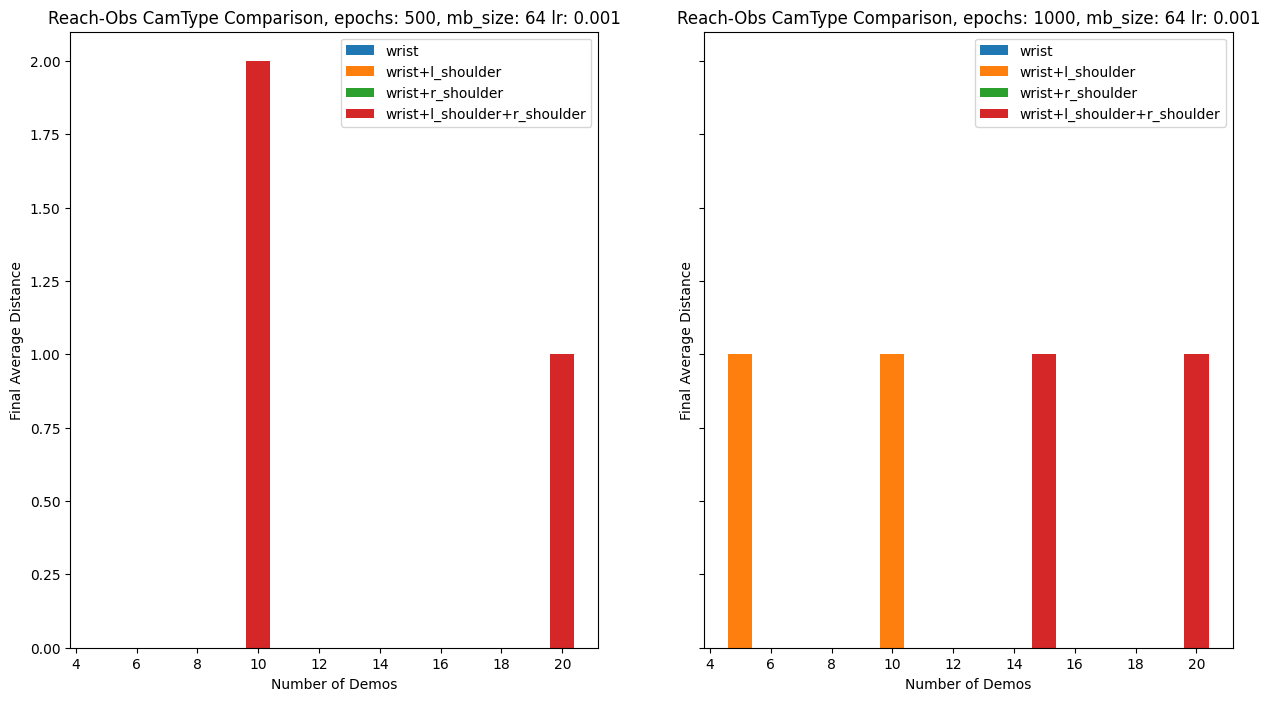

In [66]:
fig, ax = plt.subplots(1, 2, figsize=figsize, sharey=True)

for di, df in enumerate(dfs):
  for cam_type in cam_types:
    cam_df = df[df["cam_type"] == cam_type]
    ax[di].bar(cam_df["demo_count"], cam_df["reached_count"], label=cam_type)
    
  ax[di].set_title(f"Reach-Obs CamType Comparison, epochs: {epochs[di]}, mb_size: {mb} lr: {lr}")
  ax[di].set_xlabel("Number of Demos")
  ax[di].set_ylabel("Final Average Distance")
  ax[di].legend()
  
plt.show()

## Checking Policy Improvements - Training Dataset Randomisation and Sampling
None of them are particularly good, there needs to be a different mechanism to check whether the randomisation is useful 

shuffling data works well, while ingesting, this will inherently shuffle the obs as well I think, so there is not reason to use `shuffle_obs_in_demo` really

In [9]:
df = pd.read_csv("run-csvs/reach-obs/2-5-10-shuffling-checks-reachobs_random.csv")
task_name  = "ReachObs_Random"
bool_combs = product([True, False], repeat=2)

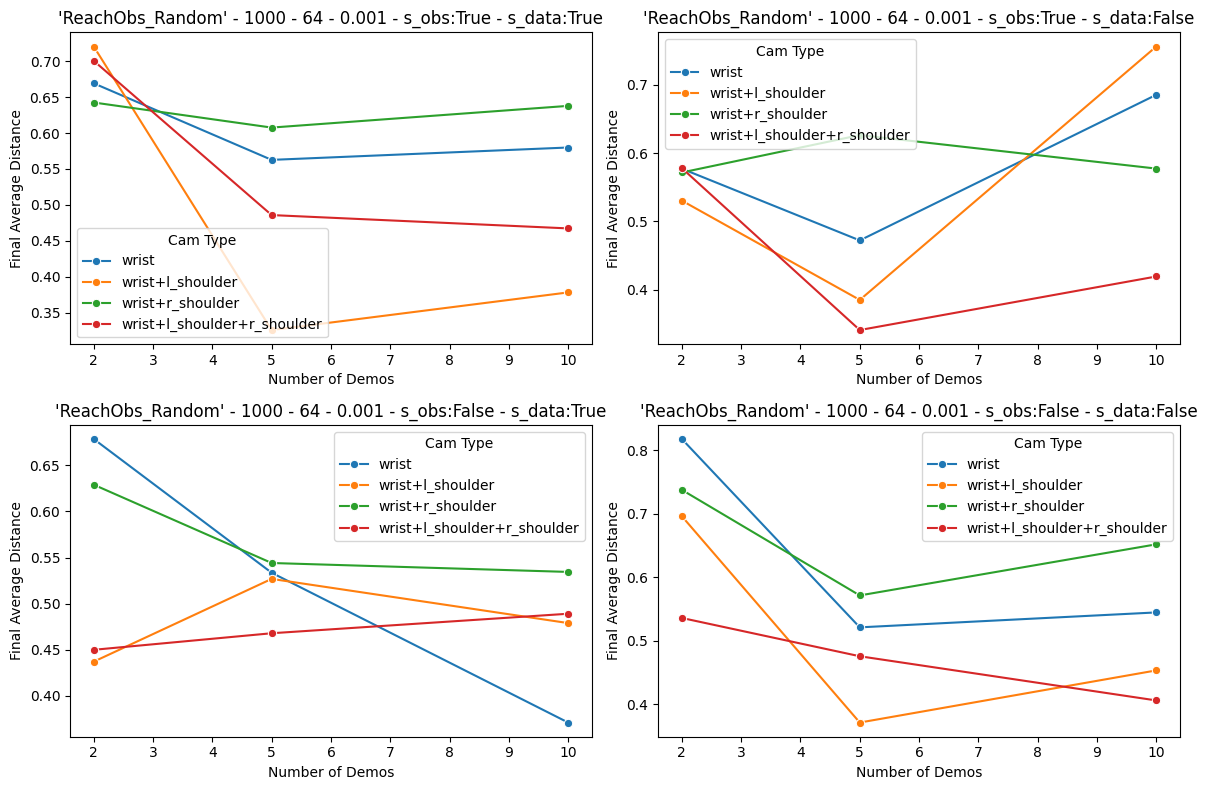

In [10]:


fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for i, (s_obs, s_data) in enumerate(bool_combs):
  opts_df = df[
    (df["shuffle_obs_in_demo"] == s_obs) &
    (df["shuffle_data"] == s_data) 
  ]
  sns.lineplot(ax=axes[i], data=opts_df, x="demo_count", y="final_dist_avg", hue="cam_type", marker="o")
  axes[i].set_title(f"'{task_name}' - 1000 - 64 - 0.001 - s_obs:{s_obs} - s_data:{s_data}")
  axes[i].set_xlabel("Number of Demos")
  axes[i].set_ylabel("Final Average Distance")
  axes[i].legend(title="Cam Type")
  

plt.tight_layout()
plt.show()


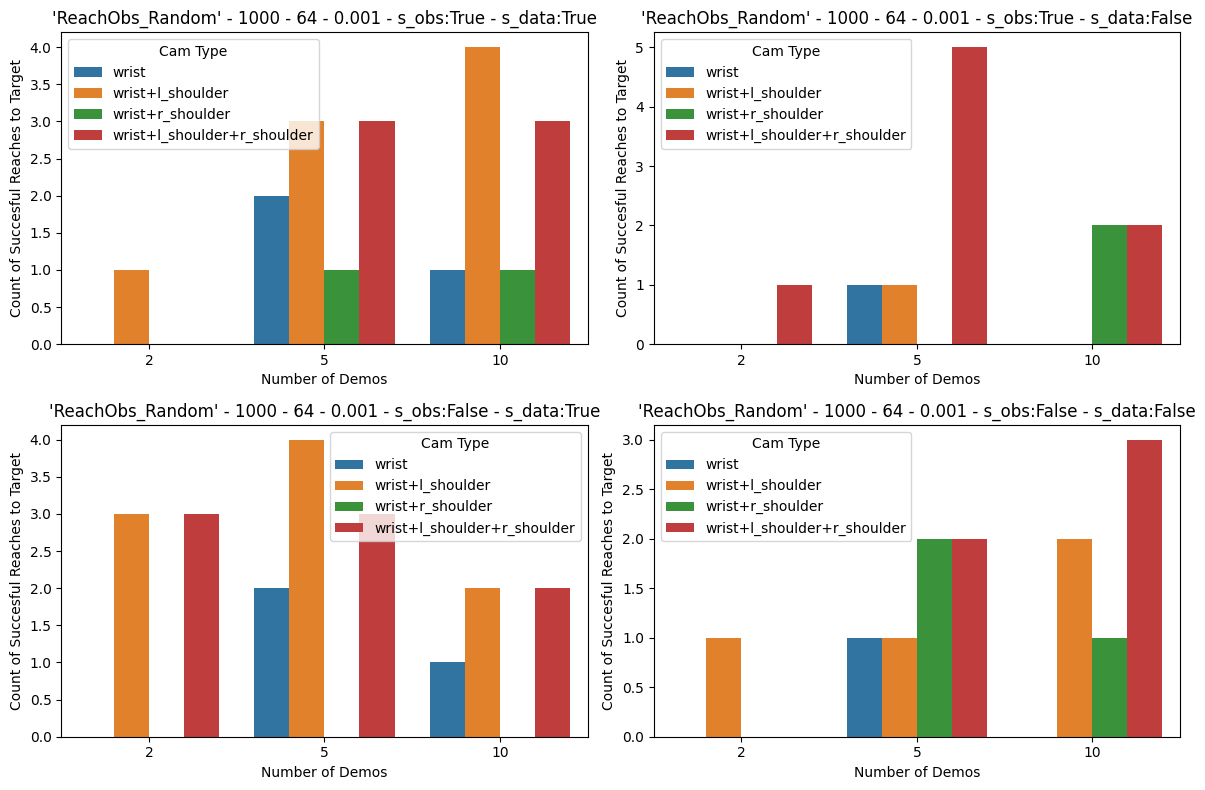

In [15]:

bool_combs = product([True, False], repeat=2)

fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for i, (s_obs, s_data) in enumerate(bool_combs):
  opts_df = df[
    (df["shuffle_obs_in_demo"] == s_obs) &
    (df["shuffle_data"] == s_data) 
  ]
  sns.barplot(ax=axes[i], data=opts_df, x="demo_count", y="reached_count", hue="cam_type")
  axes[i].set_title(f"'{task_name}' - 1000 - 64 - 0.001 - s_obs:{s_obs} - s_data:{s_data}")
  axes[i].set_xlabel("Number of Demos")
  axes[i].set_ylabel("Count of Succesful Reaches to Target")
  axes[i].legend(title="Cam Type")
  

plt.tight_layout()
plt.show()


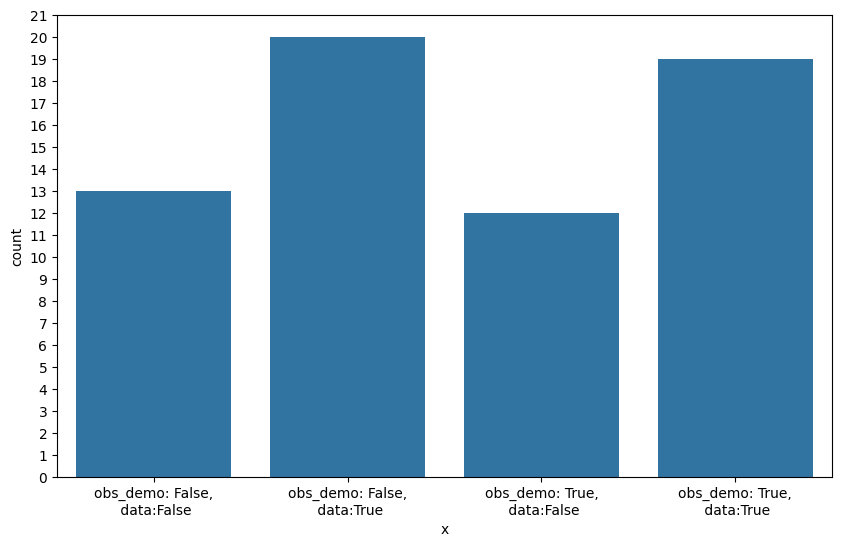

,shuffle_obs_in_demo,shuffle_data,count,x
0,False,False,13,"obs_demo: False,\n data:False"
1,False,True,20,"obs_demo: False,\n data:True"
2,True,False,12,"obs_demo: True,\n data:False"
3,True,True,19,"obs_demo: True,\n data:True"


In [18]:

grouped = df.groupby(["shuffle_obs_in_demo", "shuffle_data"])["reached_count"].apply("sum").reset_index(name = "count")
## name nicely
grouped["x"] = grouped.apply(
  lambda row: f"obs_demo: {row["shuffle_obs_in_demo"]},\n data:{row["shuffle_data"]}", axis=1
)


fig = plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, y="count", x="x")
# plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(1))
plt.show()
grouped
